# Lesson 5 : Attention 

## The Story

### It's 2014. Google Brain has a working Seq2Seq translation model. It works okay on short sentences but  falls apart on long ones — the bottleneck problem we saw last lesson.A PhD student named Dzmitry Bahdanau asks a simple question:


### "Why are we forcing the decoder to work from ONE blurry summary vector? Why not let it look back at the original sentence whenever it needs to?"


### Everyone thought this was obvious in hindsight. Nobody had done it yet.

### His 2015 paper "Neural Machine Translation by Jointly Learning to Align and Translate" introduced attention. Translation quality jumped dramatically on long sentences. The field never looked back.


Three years later, Google Brain took this idea further:

__"What if we threw away the RNN entirely and built a model made PURELY of attention?"__

That was the 2017 Transformer paper

# The Core Intuition

Translate this sentance

__"The animal didn't cross the street because it was too tired"__

When generating the word "it" in your translation , your brain automatically glances back at "animal"-- not "street", not "cross". you Know it refers to "animal".

That selective glancing back -- That's attention.

more precisely :

Decoding step: generating "it"
  
  * Look back at: "The"      → relevance: 0.02
  * Look back at: "animal"   → relevance: 0.71  ← HIGH
  * Look back at: "didn't"   → relevance: 0.01
  * Look back at: "cross"    → relevance: 0.03
  * Look back at: "street"   → relevance: 0.05
  * Look back at: "because"  → relevance: 0.02
  * Look back at: "it"       → relevance: 0.01
  * Look back at: "was"      → relevance: 0.02
  * Look back at: "too"      → relevance: 0.04
  * Look back at: "tired"    → relevance: 0.09
  
  Weighted sum of all encoder vectors (weighted by relevance scores)
  * context vector: mostly "animal", a little "tired"
  * now decode "it" from this rich, focused context

## What is Attention?

__WHAT__: A mechanism that lets a model dynamically decide which words to focus on when processing or generating each word.

__WHY__: RNNs/LSTMs read sequentially and compress everything into one vector — they forget early words in long sequences. Attention gives the model a direct line to any word, anywhere, at any time.

__WHEN__: Attention is used in every Transformer — which means BERT, GPT, LLaMA, Claude, Gemini, every modern LLM and VLM. It replaced RNNs entirely after 2018.

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# Encoder output:  one vector per INPUT word  → (src_len, hidden_dim)
# Decoder state:   one vector for CURRENT step → (hidden_dim,)
# Attention goal:  produce ONE context vector  → (hidden_dim,)
#                  = weighted sum of encoder outputs
#                  weighted by how relevant each input word is RIGHT NOW

class BhadanauAttention(nn.Module):
    def __init__(self,hidden_dim):
        super().__init__()
        # These Layers learns to score relavance
        self.w_encoder=nn.Linear(hidden_dim,hidden_dim,bias=False)
        self.w_decoder=nn.Linear(hidden_dim,hidden_dim,bias=False)
        self.v=nn.Linear(hidden_dim,1,bias=False)

    def forward(self,encoder_outputs,decoder_hidden):
        src_len=encoder_outputs.shape[0]

        enc_proj=self.w_encoder(encoder_outputs)
        dec_proj=self.w_decoder(decoder_hidden)

        combined=torch.tanh(enc_proj+dec_proj)
        scores=self.v(combined).squeeze(-1)
        attention_weights=F.softmax(scores,dim=0)

        context = (attention_weights.unsqueeze(1)*encoder_outputs).sum(0)

        return context, attention_weights

        


In [13]:
class EncoderRNN(nn.Module):
    def __init__(self,vocab_size,embed_dim,hidden_dim):
        super().__init__()
        self.embed=nn.Embedding(vocab_size,embed_dim)
        self.rnn=nn.GRU(embed_dim,hidden_dim,batch_first=False)

    def forward(self,x):
        emb=self.embed(x).unsqueeze(1)
        outputs,hidden=self.rnn(emb)
        outputs=outputs.squeeze(1)
        hidden=hidden.squeeze(0)
        return outputs,hidden
class DecoderWithAttention(nn.Module):
    def __init__(self,vocab_size,embed_dim,hidden_dim):
        super().__init__()
        self.embed=nn.Embedding(vocab_size,embed_dim)
        self.attention=BhadanauAttention(hidden_dim)

        # Input to GRU = current word embedding + context vector
        self.rnn=nn.GRU(embed_dim+hidden_dim,hidden_dim,batch_first=True)
        self.fc=nn.Linear(hidden_dim,vocab_size)

    def forward(self,input_token,hidden,encoder_outputs):
        emb=self.embed(input_token).unsqueeze(1)
        #Attention Step
        context,weights=self.attention(encoder_outputs,hidden)
        context=context.unsqueeze(0).unsqueeze(0)
        rnn_input=torch.cat([emb,context],dim=-1)
        output,hidden=self.rnn(rnn_input,hidden.unsqueeze(0))
        hidden=hidden.squeeze(0)
        prediction=self.fc(output.squeeze(0).squeeze(0))
        return prediction, hidden, weights

class seq2seqattention(nn.Module):
    def __init__(self,src_vocab,tgt_vocab,embed_dim,hidden_dim):
        super().__init__()
        self.encoder=EncoderRNN(src_vocab,embed_dim,hidden_dim)
        self.decoder=DecoderWithAttention(tgt_vocab,embed_dim,hidden_dim)

    def forward(self,src,tgt,teacher_forcing_ratio=0.5):
        encoder_outputs,hidden=self.encoder(src)

        outputs=[]
        attention_maps=[]
        decoder_input=tgt[0]

        for t in range(1,len(tgt)):
            pred,hidden,weights=self.decoder(decoder_input.unsqueeze(0),hidden,encoder_outputs)
            outputs.append(pred)
            attention_maps.append(weights.detach())


            use_teacher=torch.rand(1).item()<teacher_forcing_ratio
            decoder_input=tgt[t] if use_teacher else pred.argmax()

        return torch.stack(outputs), torch.stack(attention_maps)






In [14]:
src_sentences = [
    "the king rules the land",
    "the queen advises the king",
    "the knight protects the kingdom",
    "the wizard studies ancient magic",
    "the prince learns from the king",
]

tgt_sentences = [
    "<sos> roi gouverne la terre <eos>",
    "<sos> reine conseille le roi <eos>",
    "<sos> chevalier protege le royaume <eos>",
    "<sos> sorcier etudie la magie <eos>",
    "<sos> prince apprend du roi <eos>",
]

def build_vocab(sentences):
    words=set()
    for s in sentences:
        words.update(s.split())
    vocab=sorted(words)
    w2i={w:i for i,w in enumerate(vocab)}
    i2w={i:w for i,w in w2i.items()}
    return w2i,i2w

src_w2i,src_i2w=build_vocab(src_sentences)
tgt_w2i,tgt_i2w=build_vocab(tgt_sentences)

def encode(sentence,w2i):
    return torch.tensor([w2i[w] for w in sentence.split()],dtype=torch.long)
src_v=len(src_w2i)
tgt_v=len(tgt_w2i)
model=seq2seqattention(src_v,tgt_v,embed_dim=16,hidden_dim=32)
opt=torch.optim.Adam(model.parameters(),lr=0.01)

print("Training the model...")
for epoch in range(1000):
    total_loss=0
    for src_s, tgt_s in zip(src_sentences, tgt_sentences):
        src = encode(src_s, src_w2i)
        tgt = encode(tgt_s, tgt_w2i)
        pred, _ = model(src, tgt, teacher_forcing_ratio=0.5)
        loss = F.cross_entropy(pred, tgt[1:])
        opt.zero_grad()
        loss.backward()
        opt.step()
        total_loss += loss.item()
    if (epoch + 1) % 200 == 0:
        print(f"Epoch {epoch+1:4d}  Loss: {total_loss/len(src_sentences):.4f}")

print("\nDone training!")

Training the model...
Epoch  200  Loss: 0.0007
Epoch  400  Loss: 0.0002
Epoch  600  Loss: 0.0001
Epoch  800  Loss: 0.0000
Epoch 1000  Loss: 0.0000

Done training!


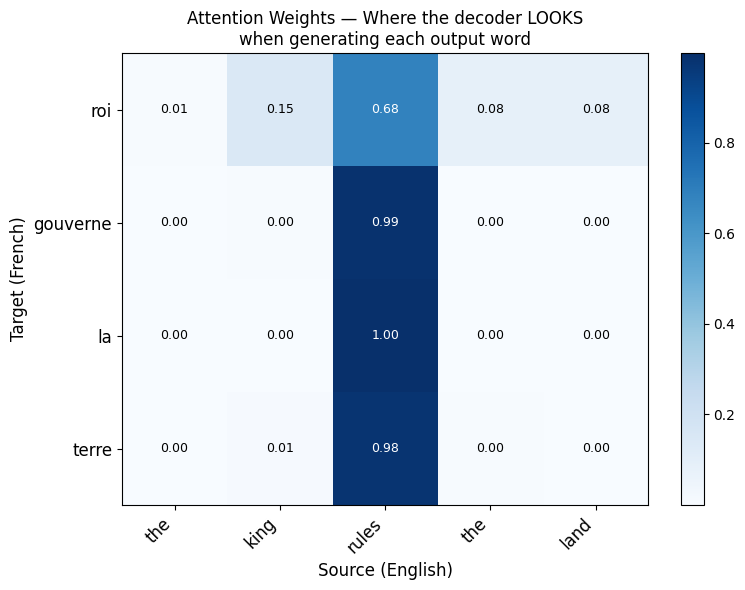

Saved to attention_viz.png


In [15]:
# ─────────────────────────────────────────────────────────────
# VISUALIZE ATTENTION — this is how researchers interpret models
# ─────────────────────────────────────────────────────────────

def visualize_attention(model, src_sentence, tgt_sentence, 
                         src_w2i, tgt_w2i, src_i2w, tgt_i2w):
    model.eval()
    src = encode(src_sentence, src_w2i)
    tgt = encode(tgt_sentence, tgt_w2i)

    with torch.no_grad():
        _, attn_maps = model(src, tgt, teacher_forcing_ratio=0.0)

    src_words = src_sentence.split()
    tgt_words = tgt_sentence.split()[1:-1]   # remove <sos> and <eos>
    attn_matrix = attn_maps[:len(tgt_words)].numpy()

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(attn_matrix, cmap='Blues', aspect='auto')

    ax.set_xticks(range(len(src_words)))
    ax.set_yticks(range(len(tgt_words)))
    ax.set_xticklabels(src_words, rotation=45, ha='right', fontsize=12)
    ax.set_yticklabels(tgt_words, fontsize=12)

    # Print weights inside cells
    for i in range(len(tgt_words)):
        for j in range(len(src_words)):
            ax.text(j, i, f"{attn_matrix[i, j]:.2f}",
                   ha='center', va='center', fontsize=9,
                   color='white' if attn_matrix[i, j] > 0.5 else 'black')

    ax.set_xlabel("Source (English)", fontsize=12)
    ax.set_ylabel("Target (French)",  fontsize=12)
    ax.set_title("Attention Weights — Where the decoder LOOKS\n"
                 "when generating each output word", fontsize=12)
    plt.colorbar(im)
    plt.tight_layout()
    plt.savefig("attention_viz.png", dpi=150)
    plt.show()
    print("Saved to attention_viz.png")

visualize_attention(
    model,
    src_sentence="the king rules the land",
    tgt_sentence="<sos> roi gouverne la terre <eos>",
    src_w2i=src_w2i, tgt_w2i=tgt_w2i,
    src_i2w=src_i2w, tgt_i2w=tgt_i2w
)

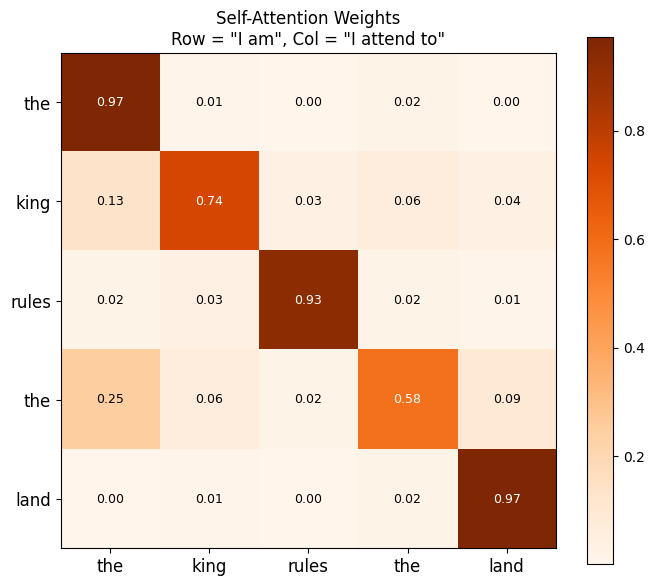


Self-attention output shape: torch.Size([5, 8])
Each word now carries information from ALL other words it attended to


In [16]:
# ─────────────────────────────────────────────────────────────
# SELF-ATTENTION — every word looks at every other word
# ─────────────────────────────────────────────────────────────

def self_attention(X):
    """
    X: (seq_len, dim) — matrix of word vectors

    Each word produces 3 vectors from its embedding:
    Q (Query)  = "what am I looking for?"
    K (Key)    = "what do I contain?"
    V (Value)  = "what do I actually give out if selected?"

    Think of it like a search engine:
    Q = your search query
    K = each webpage's title/metadata
    V = each webpage's actual content

    High dot(Q, K) = "this page is relevant to my query"
    → attend to its Value more
    """
    seq_len, dim = X.shape

    # In a real Transformer, W_Q/W_K/W_V are learned linear projections.
    # Here we use the raw embeddings as Q, K, V for simplicity.
    Q = X   # (seq_len, dim)
    K = X   # (seq_len, dim)
    V = X   # (seq_len, dim)

    # Score: how much does each word (Q) want to attend to each other word (K)?
    scores = torch.matmul(Q, K.T)              # (seq_len, seq_len)

    # Scale by sqrt(dim) — prevents scores from growing too large
    # (large scores → softmax saturates → gradients vanish, the old enemy)
    scores = scores / (dim ** 0.5)

    # Softmax: convert scores to attention weights (each row sums to 1)
    weights = F.softmax(scores, dim=-1)        # (seq_len, seq_len)

    # Weighted sum of Values — the output for each word
    output = torch.matmul(weights, V)          # (seq_len, dim)

    return output, weights


# Demo on a tiny sentence
sentence = ["the", "king", "rules", "the", "land"]
vocab    = sorted(set(sentence))
w2i      = {w: i for i, w in enumerate(vocab)}

# Create simple embeddings (in real model these come from embedding table)
torch.manual_seed(42)
X = torch.randn(len(sentence), 8)   # (5 words, 8-dim embeddings)

output, weights = self_attention(X)

# Visualize self-attention
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(weights.detach().numpy(), cmap='Oranges')
ax.set_xticks(range(len(sentence)))
ax.set_yticks(range(len(sentence)))
ax.set_xticklabels(sentence, fontsize=12)
ax.set_yticklabels(sentence, fontsize=12)
ax.set_title('Self-Attention Weights\nRow = "I am", Col = "I attend to"',
             fontsize=12)

for i in range(len(sentence)):
    for j in range(len(sentence)):
        ax.text(j, i, f"{weights[i,j].item():.2f}",
               ha='center', va='center', fontsize=9,
               color='white' if weights[i,j].item() > 0.5 else 'black')

plt.colorbar(im)
plt.tight_layout()
plt.savefig("self_attention.png", dpi=150)
plt.show()

print("\nSelf-attention output shape:", output.shape)
print("Each word now carries information from ALL other words it attended to")